In [1]:
import pandas as pd 
import torch
import numpy as np
import random
import os
from matplotlib import pyplot as plt

def set_seed(seed: int = 42) -> None:
    """Sets the random seed for reproducibility across PyTorch, NumPy, and Python's random module."""
    os.environ['PYTHONHASHSEED'] = str(seed)  # For Python's hash seed
    torch.manual_seed(seed)  # For PyTorch's CPU and CUDA RNGs
    torch.cuda.manual_seed(seed)  # For CUDA devices specifically
    torch.cuda.manual_seed_all(seed) # For all CUDA devices if multiple are used
    np.random.seed(seed)  # For NumPy's random number generator
    random.seed(seed)  # For Python's built-in random module

    # For deterministic algorithms in PyTorch (optional, but recommended for full reproducibility)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Example usage:
set_seed(123)

In [7]:
import sys
import os

# Add project root (parent of "src") to Python path
sys.path.append(os.path.abspath(".."))

from src.data_loader import load_OhioT1DM

Ohio_PATH = "..\data\\raw\\"
X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = load_OhioT1DM(path=Ohio_PATH, look_back=120, test_size = None)
X_test, y_reg_test, y_clf_test = load_OhioT1DM(path=Ohio_PATH, look_back=120, train=False)

In [8]:
import glob 
import re

generated_PATH = "..\data\\generated\\synth_**.pt"

generated_paths  = glob.glob(generated_PATH) 

pattern = r"synth_(\w+)\.pt"  # capture word characters between 'synth_' and '.pt'

generated_data = {}

for path in generated_paths: 
    
    data = torch.load(path)
    
    file_name = path.split("\\")[-1]
    match = re.search(pattern, file_name)
    generator = match.group(1)
    generated_data[generator] = np.array(data)
        
    print(f"synth data generated by {generator} loaded: {file_name} .")



synth data generated by gan loaded: synth_gan.pt .
synth data generated by vae loaded: synth_vae.pt .


## Statistical Fidelity

Higher-Order Statistics: Compare overall behavior

In [ ]:
from scipy.stats import skew, kurtosis

summary = lambda x: (np.mean(x), np.std(x), skew(x), kurtosis(x))
print("Real:", summary(X_train.ravel()))
print("Synth:", summary(np.array(data.flatten())))


Real: (157.39487, 58.11715, 0.6100782006652294, 0.17020502733359733)
Synth: (129.21126, 32.809753, 0.6774864625676139, 3.3223186251299985)


Marginal Distribution Comparison: Compare glucose range/shape

In [17]:
from scipy.stats import ks_2samp
import numpy as np

# real and synth are 1D numpy arrays or flattened lists of values
ks_stat, p_val = ks_2samp(X_train.ravel(), data.ravel())

print(f"KS statistic = {ks_stat:.4f}, p-value = {p_val:.4f}")


KS statistic = 0.5002, p-value = 0.0000


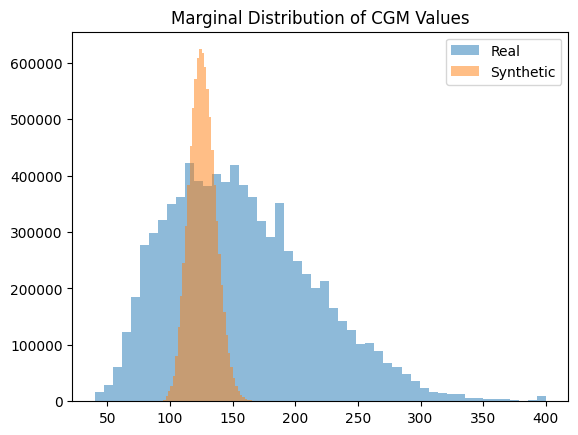

In [16]:
import matplotlib.pyplot as plt

plt.hist(X_train.ravel(), bins=50, alpha=0.5, label="Real")
plt.hist(data.ravel(), bins=50, alpha=0.5, label="Synthetic")
plt.legend(); plt.title("Marginal Distribution of CGM Values")
plt.show()


Temporal Dependence (Dynamics): Check lag dependencies

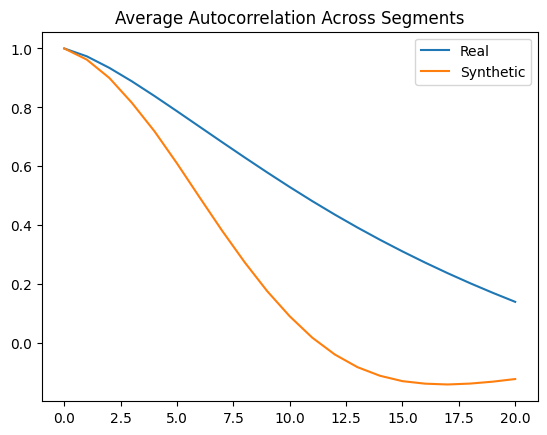

ACF difference: 1.5306


In [38]:
from statsmodels.tsa.stattools import acf

def mean_acf(X, nlags=20):
    acfs = []
    for row in X:
        acfs.append(acf(row, nlags=nlags))
    return np.mean(acfs, axis=0)

acf_real = mean_acf(X_train)
acf_synth = mean_acf(data)

plt.plot(acf_real, label="Real")
plt.plot(acf_synth, label="Synthetic")
plt.legend(); plt.title("Average Autocorrelation Across Segments")
plt.show()

acf_diff = np.linalg.norm(acf_real - acf_synth)
print(f"ACF difference: {acf_diff:.4f}")


In [22]:
import numpy as np
acf_diff = np.linalg.norm(acf_real - acf_synth)
print(f"ACF difference: {acf_diff:.4f}")


ACF difference: 1.2416


Spectral Properties (Frequency Domain): Compare periodicity

c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 128, using nperseg = 128
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


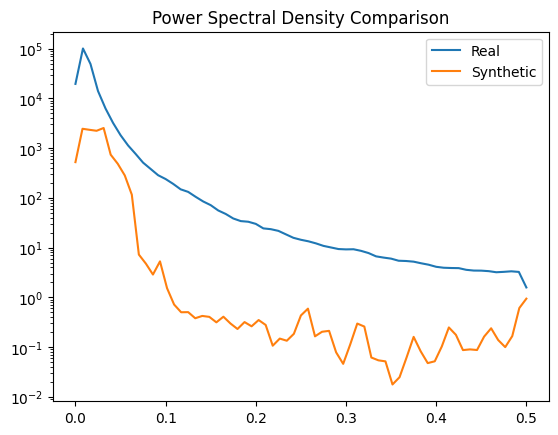

In [33]:
from scipy.signal import welch

f_real, Pxx_real = welch(X_train, nperseg=120)
f_synth, Pxx_synth = welch(data, nperseg=256)

plt.semilogy(f_real, Pxx_real.mean(axis=0), label='Real')
plt.semilogy(f_synth, Pxx_synth.mean(axis=0).ravel(), label='Synthetic')
plt.legend(); plt.title("Power Spectral Density Comparison")
plt.show()


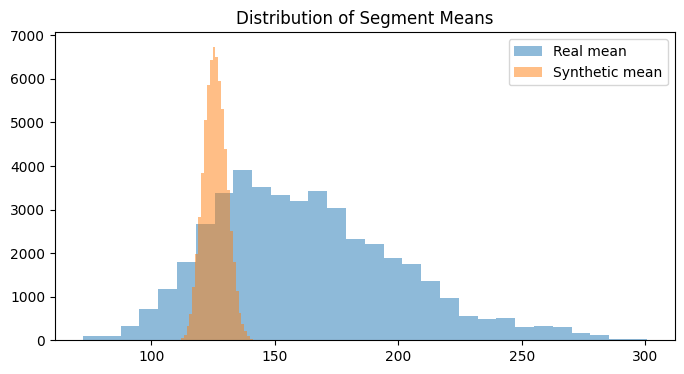

KS mean=0.723, KS var=0.974


In [ ]:
mean_real = X_train.mean(axis=1)
mean_synth = data.mean(axis=1)

var_real = X_train.var(axis=1)
var_synth = data.var(axis=1)

plt.figure(figsize=(8,4))
plt.hist(mean_real, bins=30, alpha=0.5, label="Real mean")
plt.hist(mean_synth, bins=30, alpha=0.5, label="Synthetic mean")
plt.legend(); plt.title("Distribution of Segment Means")
plt.show()

ks_mean, _ = ks_2samp(mean_real, mean_synth)
ks_var, _  = ks_2samp(var_real, var_synth)
print(f"KS mean={ks_mean:.3f}, KS var={ks_var:.3f}")
